Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot") # gives professional apprearance of graph
df = pd.read_csv("C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Data\\netflix_titles.csv")
df.head() # verification of the dataset being loaded correctly

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Dataset Overview

In [2]:
print(df.shape) # number of rows and columns
print()
df.info() #general information of the file. Like Column names, Missing values, Data types,  Memory usage
print()
df.describe(include="all") #provides summary statistics

(8807, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Data Cleaning

In [3]:
#Removing Unnecessary Columns
df.drop(columns=['show_id'], inplace=True)

#Removing Leading/Trailing Spaces
columnsss = df.columns
for col in columnsss:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

#Handling duplicates
print(df.isnull().sum()) # Checks and tells number of missing values
print()
print(df.duplicated().sum()) # Check for duplicate rows
# if duplicates existed, then "print(df.drop_duplicates(inplace=True))" would be used, it Deletes duplicate rows
print()

#Handling missing values
# We can see that in columns "Director" "cast" "country" have a decent amount of missing values in rows so we can't delete those rows because that would be losing a large amount of data which can be used for analysis. so instead we replace the NaN with "Unknown"
df['director'] = df['director'].fillna('Unknown') # replaces missing values with "Unknown"
df['cast'] = df['cast'].fillna('Unknown') # replaces missing values with "Unknown"
df['country'] = df['country'].fillna('Unknown') # replaces missing values with "Unknown"

# We can also see that in columns "date_added" "rating" "duration" have a very low percentage of missing values, so we can delete them without worries
df = df.dropna(subset=['date_added']) #deletes all the rows having missing values
df = df.dropna(subset=['rating']) #deletes all the rows having missing values
df = df.dropna(subset=['duration']) #deletes all the rows having missing values

print(df.isnull().sum()) #verifying that all missing values are handled

#Converting data types
df['date_added'] = pd.to_datetime(df['date_added']) # converts the dates which are currently string into python understandable dates i.e converted the data type from "object" or string to "datetime[64]"

#Feature engineering
df['year_added'] = df['date_added'].dt.year # creates a new column where only year added would be shown
df['month_added'] = df['date_added'].dt.month # creates a new column where only month added would be shown
df['day_added'] = df['date_added'].dt.day # creates a new column where only day added would be shown
print(df[['date_added','year_added','month_added','day_added']].head()) # verification of newly added columns




type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

1

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
  date_added  year_added  month_added  day_added
0 2021-09-25        2021            9         25
1 2021-09-24        2021            9         24
2 2021-09-24        2021            9         24
3 2021-09-24        2021            9         24
4 2021-09-24        2021            9         24


Save Cleaned Dataset

In [4]:
df.to_csv("C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Data\\netflix_cleaned.csv")

Visualization

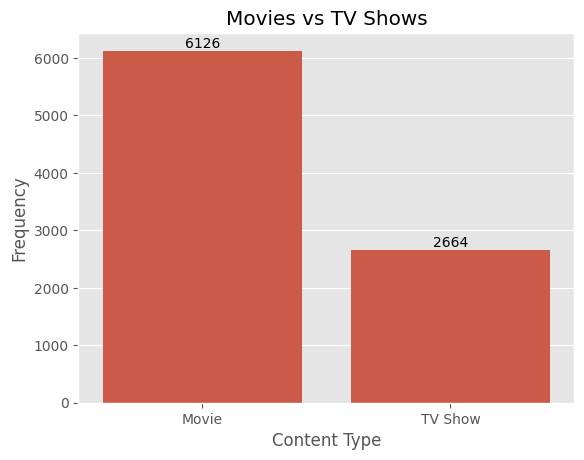

In [5]:
x = sns.countplot(
    data=df, # gives df as reference data
    x="type" # tells seaborn to use "type" column's rows on the x axis
)
for i in x.containers:
    x.bar_label(i) # this for loop shows the actual numerical values of bar graphs above them

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Frequency")

plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\01_movies_vs_tvshows.png",
    dpi = 300,
    bbox_inches = 'tight'
    )

plt.show()

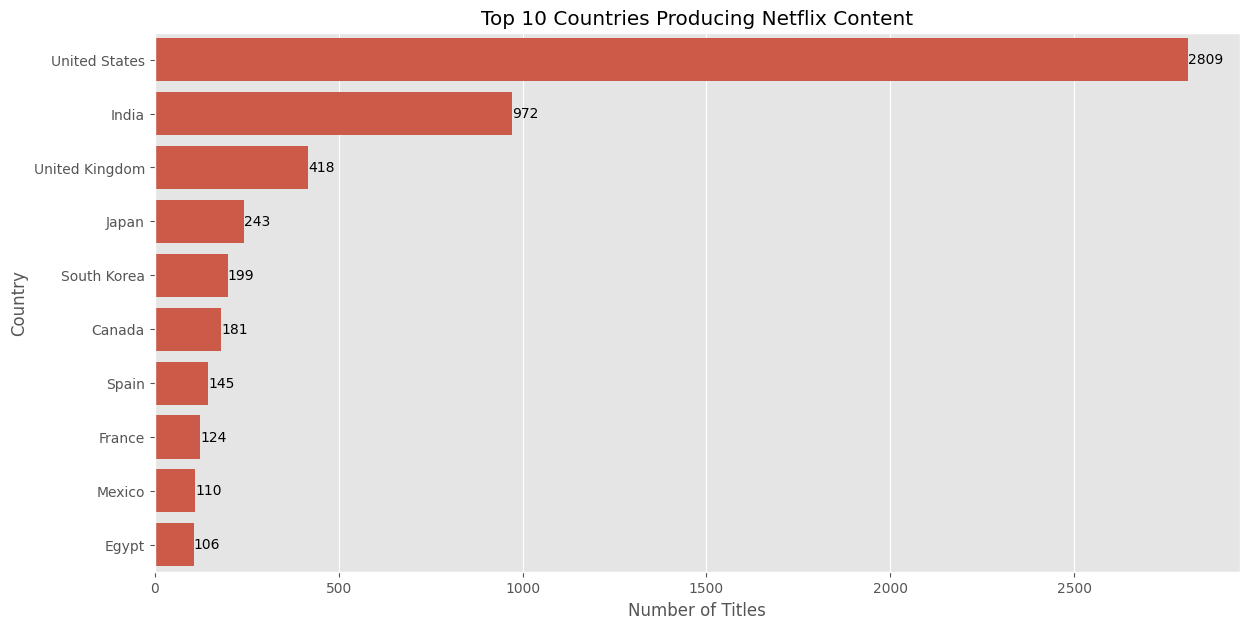

In [6]:
country_counts = (
    df[df['country'] != 'Unknown']['country'] # Removes the "Unknown" values in the dataset because "Unknown" is not an actual country and it cannot be used for analysis
    .value_counts()
    .head(10)
)
plt.figure(figsize=(14,7))
x = sns.barplot(
    x = country_counts.values,
    y = country_counts.index,
)
for i in x.containers:
    x.bar_label(i)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\02_top_10_countries.png",
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()


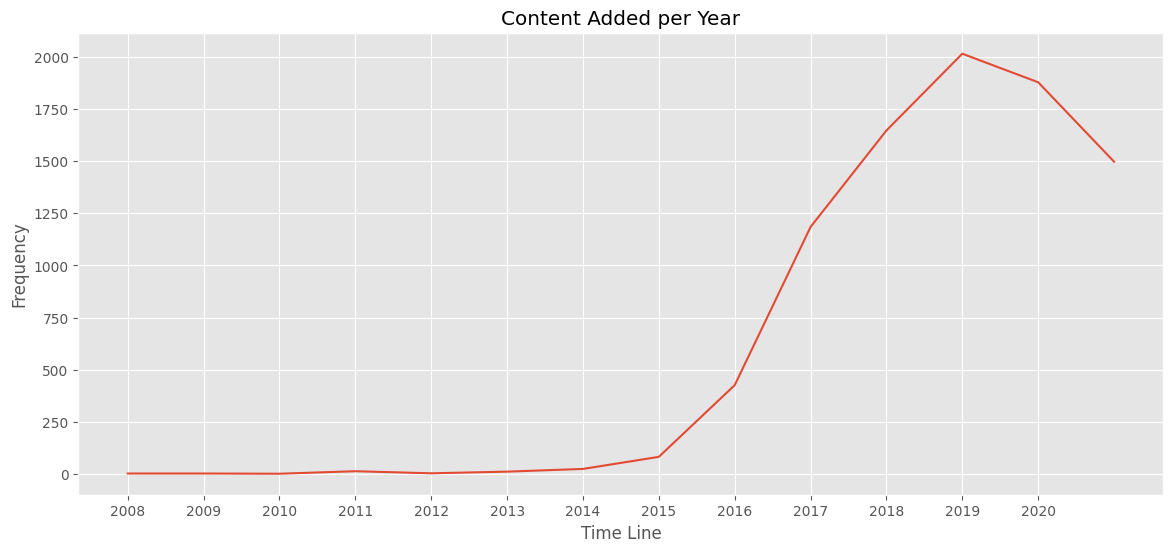

In [7]:
content_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(14,6))
plt.plot(
    content_per_year.index,
    content_per_year.values,
)
plt.xticks(range(2008, 2021, 1))
plt.title("Content Added per Year")
plt.xlabel("Time Line")
plt.ylabel("Frequency")
plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\03_content_added_per_year",
)
plt.show()

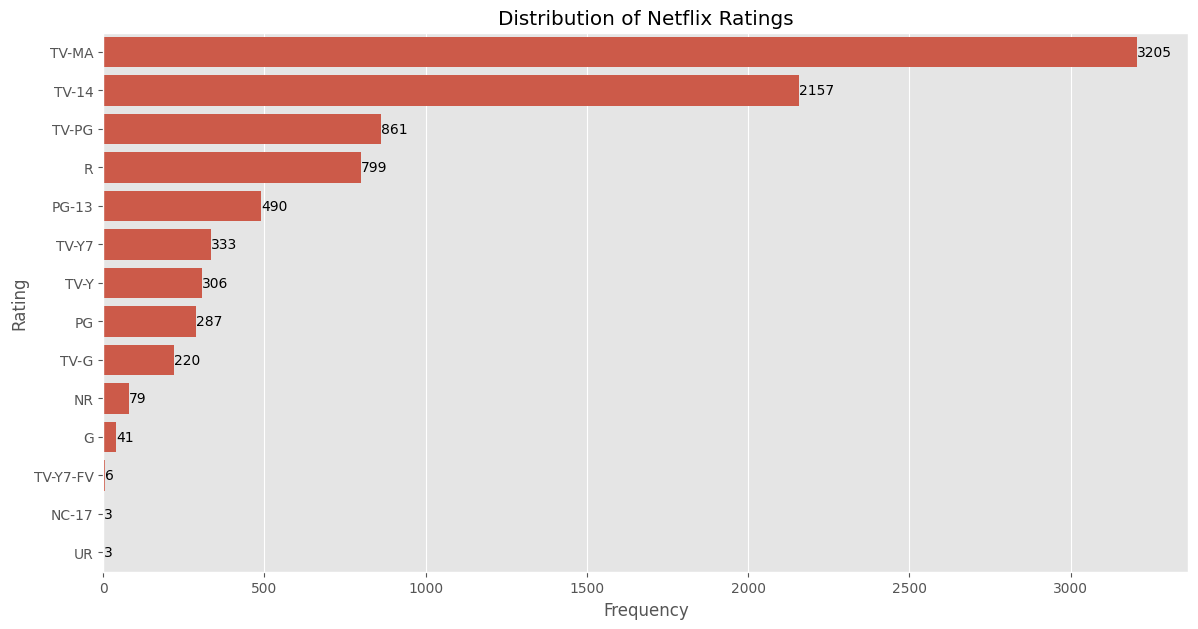

In [8]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(14,7))
a = sns.barplot(
    x = rating_counts.values,
    y = rating_counts.index,
)
for i in a.containers:
    a.bar_label(i)
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Frequency")
plt.ylabel("Rating")
plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\04_netflix_rating.png",
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

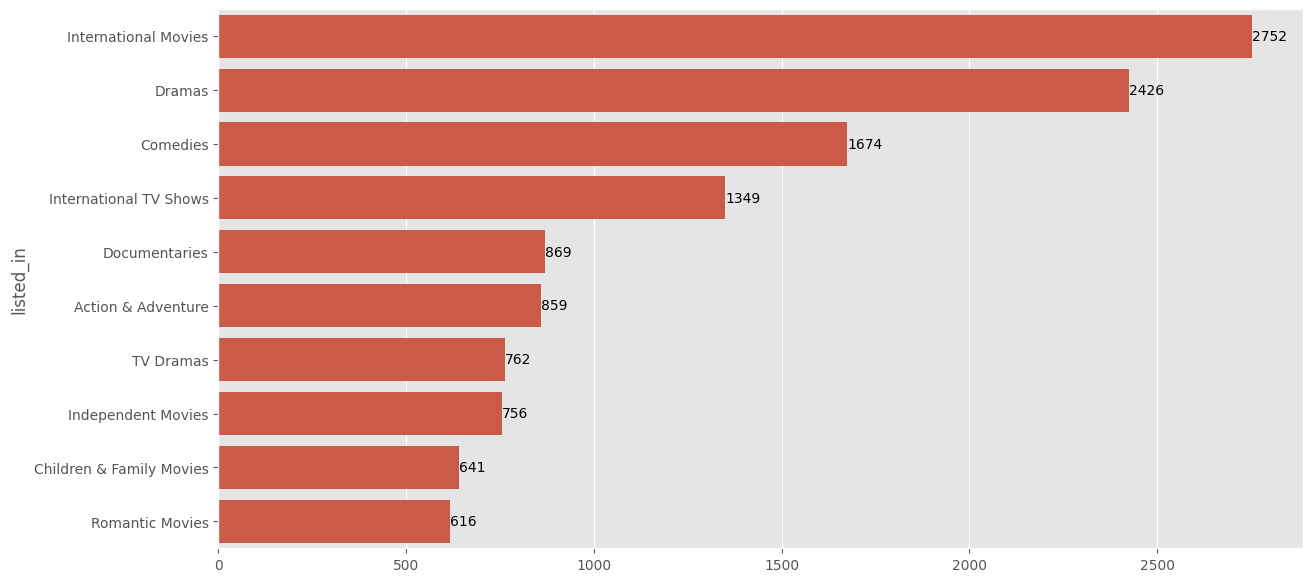

In [9]:
genre = df['listed_in'].str.split(', ')
genre = genre.explode()

genre_counts = genre.value_counts().head(10)

plt.figure(figsize=(14,7))
a = sns.barplot(
    x = genre_counts.values,
    y = genre_counts.index,
)
for i in a.containers:
    a.bar_label(i)
plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\05_genres.png",
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

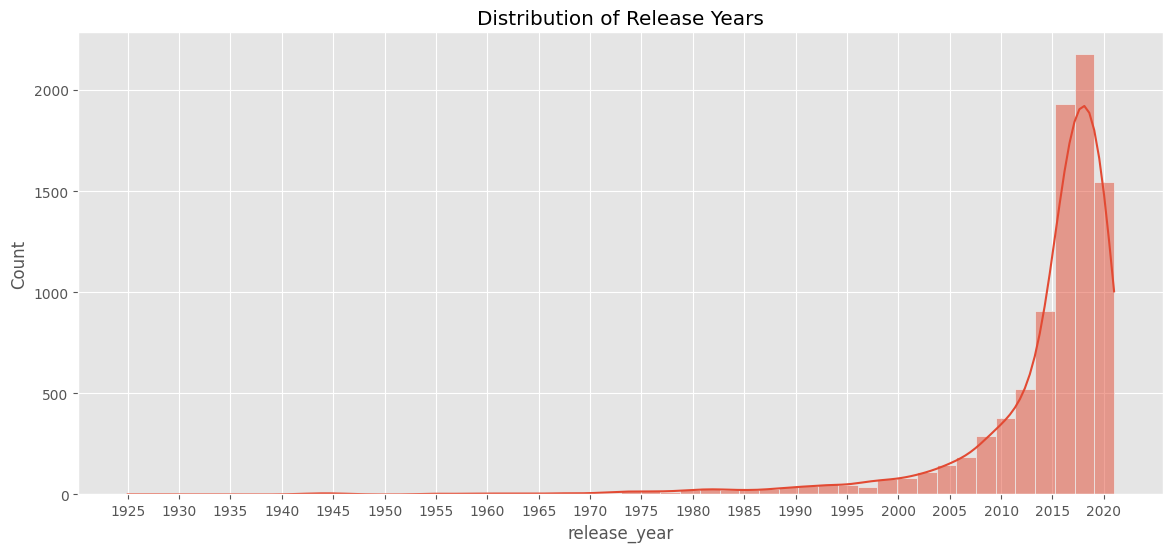

In [10]:
plt.figure(figsize=(14,6)) # (width, length) in inches
sns.histplot(
    data = df, # gives df as reference data
    x = "release_year", # tells seaborn to use "release_year" column's rows on the x axis
    bins = 50, # creates 50 bins
    kde = True #KDE = Kernel Density Estimation. It draws a smooth curve over the histogram.
)
plt.title("Distribution of Release Years")
plt.xticks(range(1925, 2021, 5)) # change the number of intervals on the x axis
plt.savefig(
    "C:\\Users\\Supriya Chinchpure\\Desktop\\Girish\\Data Cleaning and Visualisation Project\\Visuals\\06_dist_of_release_years.png",
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

Key Insights

1) Movies dominate Netflix's platform with approximate 70% of content as movies and rest 30% of content as TV Shows.

2) The United States contribute to the highest amount of producing Netflix Content with 2809 titles which is roughly 32%, and India follows with 972 titles which is roughly 11.08%.

3) From 2008 to 2014, there was negligible content added to Netflix. Then from 2014 to 2016 we can see a steady growth in the content added. From 2016 to 2019 we can see a rapid growth in adding content on Netflix.

4) TV-MA and TV-14 are the most common content ratings, together accounting for more than 60% of content. This indicates that Netflix targets teenage and adult audience.

5) International Movies, Dramas and Comedies are the most popular genres on Netflix. Prominent titles of International Movies and International TV Shows shows Netflix's target audience to be global.

6) The release year distribution shows that most titles on Netflix were released after 2000.

Conclusion

This project focused on cleaning, preprocessing, analyzing, and visualizing the Netflix Movies and TV Shows dataset using Python. The dataset was cleaned by handling missing values, removing inconsistencies, converting data types, and creating new features for time-based analysis. Exploratory Data Analysis (EDA) was then performed to understand content distribution, country-wise contributions, content growth trends, ratings, genres, and release years.

Overall, this project demonstrates the complete workflow of a data cleaning and visualization pipeline using Pandas, Matplotlib, and Seaborn, while providing meaningful insights into Netflix's content library.